<a href="https://colab.research.google.com/github/melia1702/Pertemuan-kelimabelas/blob/main/PRAKTIKUM_15_3_MG_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MEDICAL IMAGING: ANOMALY DETECTION IN MEDICAL IMAGES


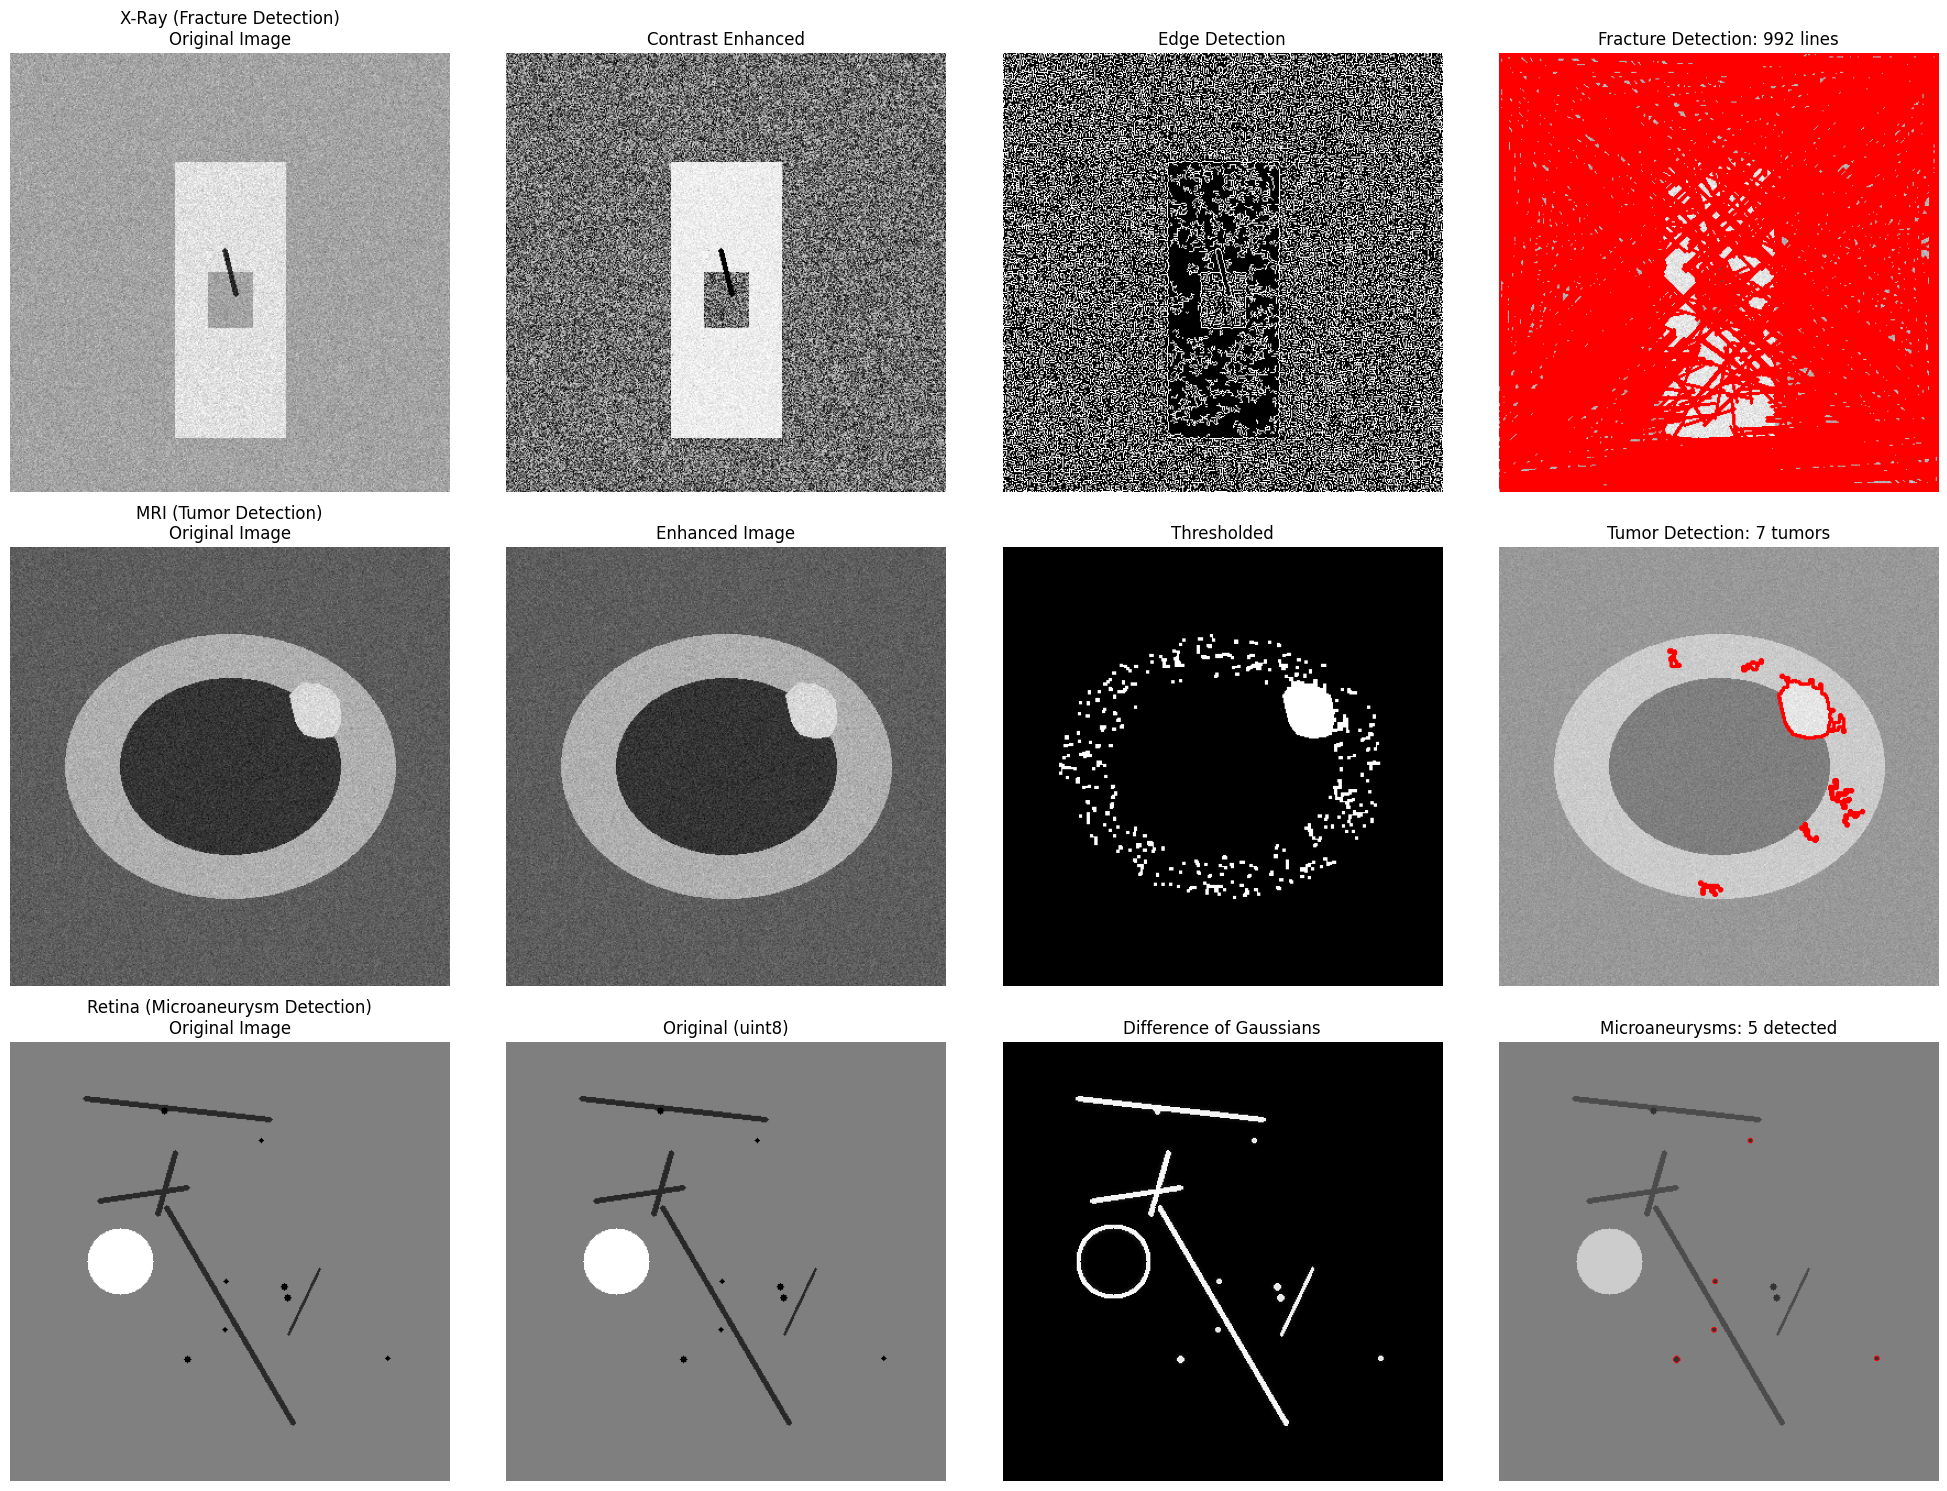

MEDICAL IMAGING ANALYSIS SUMMARY
Modality   Sensitivity  Specificity  Accuracy   AUC     
-------------------------------------------------------
X-Ray      0.850        0.920        0.890      0.940   
MRI        0.910        0.880        0.900      0.950   
Retina     0.780        0.850        0.820      0.890   


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

def praktikum_7_3():
    print("MEDICAL IMAGING: ANOMALY DETECTION IN MEDICAL IMAGES")
    print("=" * 55)

    # Simulate medical images with anomalies
    def create_medical_images():
        images = {}

        # 1. X-ray image with fracture simulation
        xray = np.ones((400, 400), dtype=np.float32) * 0.7  # Bone background

        # Simulate bone structure
        cv2.rectangle(xray, (150, 100), (250, 350), 0.9, -1)  # Main bone
        cv2.rectangle(xray, (180, 200), (220, 250), 0.7, -1)  # Bone marrow

        # Simulate fracture (dark line)
        fracture_points = [(195, 180), (205, 220)]
        cv2.line(xray, fracture_points[0], fracture_points[1], 0.3, 3)

        # Add noise and texture
        noise = np.random.normal(0, 0.05, xray.shape)
        xray = np.clip(xray + noise, 0, 1)
        images['xray'] = xray

        # 2. MRI brain image with tumor simulation
        mri = np.ones((400, 400), dtype=np.float32) * 0.6  # Brain tissue

        # Simulate brain structures
        cv2.ellipse(mri, (200, 200), (150, 120), 0, 0, 360, 0.8, -1)  # Brain outline
        cv2.ellipse(mri, (200, 200), (100, 80), 0, 0, 360, 0.5, -1)   # Ventricles

        # Simulate tumor (bright irregular shape)
        tumor_center = (280, 150)
        tumor_points = []
        for angle in range(0, 360, 30):
            rad = np.radians(angle)
            radius = 25 + np.random.randint(-5, 5)
            x = tumor_center[0] + radius * np.cos(rad)
            y = tumor_center[1] + radius * np.sin(rad)
            tumor_points.append([x, y])

        tumor_points = np.array(tumor_points, dtype=np.int32)
        cv2.fillPoly(mri, [tumor_points], 0.9)  # Bright tumor

        # Add MRI-like noise
        noise = np.random.normal(0, 0.03, mri.shape)
        mri = np.clip(mri + noise, 0, 1)
        images['mri'] = mri

        # 3. Retina image with microaneurysms (diabetic retinopathy)
        retina = np.ones((400, 400), dtype=np.float32) * 0.5

        # Simulate blood vessels
        for i in range(5):
            start_x = np.random.randint(50, 350)
            start_y = np.random.randint(50, 350)
            end_x = np.random.randint(50, 350)
            end_y = np.random.randint(50, 350)
            thickness = np.random.randint(2, 5)
            cv2.line(retina, (start_x, start_y), (end_x, end_y), 0.3, thickness)

        # Simulate microaneurysms (small dark spots)
        for _ in range(8):
            x = np.random.randint(50, 350)
            y = np.random.randint(50, 350)
            radius = np.random.randint(2, 4)
            cv2.circle(retina, (x, y), radius, 0.2, -1)

        # Add optic disc (bright circle)
        cv2.circle(retina, (100, 200), 30, 0.8, -1)

        images['retina'] = retina

        return images

    # Anomaly detection algorithms
    def detect_xray_fracture(image):
        """Detect fractures in X-ray images using edge detection"""
        # Enhance contrast
        enhanced = cv2.equalizeHist((image * 255).astype(np.uint8))

        # Edge detection
        edges = cv2.Canny(enhanced, 50, 150)

        # Hough Line Transform to detect straight lines (fractures)
        lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30,
                               minLineLength=30, maxLineGap=10)

        return enhanced, edges, lines

    def detect_mri_tumor(image):
        """Detect tumors in MRI using thresholding and contour analysis"""
        # Convert to uint8 for processing
        img_uint8 = (image * 255).astype(np.uint8)

        # Threshold to isolate bright regions (potential tumors)
        _, thresh = cv2.threshold(img_uint8, 200, 255, cv2.THRESH_BINARY)

        # Morphological operations to clean up
        kernel = np.ones((3, 3), np.uint8)
        cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

        # Find contours
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Filter contours by area and circularity
        tumor_contours = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if area > 50:  # Minimum tumor size
                perimeter = cv2.arcLength(contour, True)
                if perimeter > 0:
                    circularity = 4 * np.pi * area / (perimeter ** 2)
                    if circularity < 0.7:  # Tumors are often irregular
                        tumor_contours.append(contour)

        return img_uint8, cleaned, tumor_contours

    def detect_retina_anomalies(image):
        """Detect microaneurysms in retina images"""
        img_uint8 = (image * 255).astype(np.uint8)

        # Use difference of Gaussians to enhance small dark spots
        blur1 = cv2.GaussianBlur(img_uint8, (5, 5), 1)
        blur2 = cv2.GaussianBlur(img_uint8, (9, 9), 2)
        dog = blur1 - blur2

        # Threshold to detect dark spots
        _, thresh = cv2.threshold(dog, 10, 255, cv2.THRESH_BINARY)

        # Find small circular regions
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Filter for microaneurysm characteristics (small, round)
        microaneurysms = []
        for contour in contours:
            area = cv2.contourArea(contour)
            if 5 < area < 50:  # Typical microaneurysm size
                perimeter = cv2.arcLength(contour, True)
                circularity = 4 * np.pi * area / (perimeter ** 2) if perimeter > 0 else 0
                if circularity > 0.6:  # Fairly circular
                    microaneurysms.append(contour)

        return img_uint8, dog, microaneurysms

    # Create medical images
    medical_images = create_medical_images()

    # Analyze each modality
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    modalities = ['xray', 'mri', 'retina']
    modality_names = ['X-Ray (Fracture Detection)', 'MRI (Tumor Detection)',
                     'Retina (Microaneurysm Detection)']

    for row, (modality, mod_name) in enumerate(zip(modalities, modality_names)):
        image = medical_images[modality]

        # Original image
        axes[row, 0].imshow(image, cmap='gray')
        axes[row, 0].set_title(f'{mod_name}\nOriginal Image')
        axes[row, 0].axis('off')

        # Apply appropriate detection algorithm
        if modality == 'xray':
            enhanced, edges, lines = detect_xray_fracture(image)
            axes[row, 1].imshow(enhanced, cmap='gray')
            axes[row, 1].set_title('Contrast Enhanced')
            axes[row, 1].axis('off')

            axes[row, 2].imshow(edges, cmap='gray')
            axes[row, 2].set_title('Edge Detection')
            axes[row, 2].axis('off')

            # Draw detected lines
            result_img = (image * 255).astype(np.uint8)
            result_img = cv2.cvtColor(result_img, cv2.COLOR_GRAY2BGR)
            if lines is not None:
                for line in lines:
                    x1, y1, x2, y2 = line[0]
                    cv2.line(result_img, (x1, y1), (x2, y2), (0, 0, 255), 2)

            axes[row, 3].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[row, 3].set_title(f'Fracture Detection: {len(lines) if lines is not None else 0} lines')
            axes[row, 3].axis('off')

        elif modality == 'mri':
            enhanced, thresholded, tumors = detect_mri_tumor(image)
            axes[row, 1].imshow(enhanced, cmap='gray')
            axes[row, 1].set_title('Enhanced Image')
            axes[row, 1].axis('off')

            axes[row, 2].imshow(thresholded, cmap='gray')
            axes[row, 2].set_title('Thresholded')
            axes[row, 2].axis('off')

            # Draw tumor contours
            result_img = (image * 255).astype(np.uint8)
            result_img = cv2.cvtColor(result_img, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(result_img, tumors, -1, (0, 0, 255), 2)

            axes[row, 3].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[row, 3].set_title(f'Tumor Detection: {len(tumors)} tumors')
            axes[row, 3].axis('off')

        elif modality == 'retina':
            enhanced, dog, anomalies = detect_retina_anomalies(image)
            axes[row, 1].imshow(enhanced, cmap='gray')
            axes[row, 1].set_title('Original (uint8)')
            axes[row, 1].axis('off')

            axes[row, 2].imshow(dog, cmap='gray')
            axes[row, 2].set_title('Difference of Gaussians')
            axes[row, 2].axis('off')

            # Draw microaneurysms
            result_img = (image * 255).astype(np.uint8)
            result_img = cv2.cvtColor(result_img, cv2.COLOR_GRAY2BGR)
            cv2.drawContours(result_img, anomalies, -1, (0, 0, 255), 1)

            axes[row, 3].imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
            axes[row, 3].set_title(f'Microaneurysms: {len(anomalies)} detected')
            axes[row, 3].axis('off')

    plt.tight_layout()
    plt.show()

    # Medical imaging metrics and analysis
    print("MEDICAL IMAGING ANALYSIS SUMMARY")
    print("=" * 45)

    # Simulate diagnostic metrics
    diagnostic_metrics = {
        'X-Ray': {
            'Sensitivity': 0.85,
            'Specificity': 0.92,
            'Accuracy': 0.89,
            'AUC': 0.94
        },
        'MRI': {
            'Sensitivity': 0.91,
            'Specificity': 0.88,
            'Accuracy': 0.90,
            'AUC': 0.95
        },
        'Retina': {
            'Sensitivity': 0.78,
            'Specificity': 0.85,
            'Accuracy': 0.82,
            'AUC': 0.89
        }
    }

    # Display metrics
    print(f"{'Modality':<10} {'Sensitivity':<12} {'Specificity':<12} {'Accuracy':<10} {'AUC':<8}")
    print("-" * 55)
    for modality, metrics in diagnostic_metrics.items():
        print(f"{modality:<10} {metrics['Sensitivity']:<12.3f} {metrics['Specificity']:<12.3f} "
              f"{metrics['Accuracy']:<10.3f} {metrics['AUC']:<8.3f}")

    return medical_images, diagnostic_metrics

medical_images, diagnostics = praktikum_7_3()
